<a href="https://colab.research.google.com/github/danielruizm16/ComputationalMethods_2026_I/blob/main/Álgebra_Lineal/Álgebra_Lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Álgebra lineal


In [1]:
import numpy as np

# 1.

El **teorema de Laplace** es un método para calcular el determinante de una matriz cuadrada, especialmente útil para matrices de orden mayor que 2. Este teorema se basa en la expansión del determinante por los elementos de cualquier fila o columna.

$$
\det(A) = \sum_{j=1}^n (-1)^{1+j} a_{1j} M_{1j}
$$

donde:
- $a_{1j}$ es el elemento de la primera fila y la columna $j$.
- $M_{1j}$ es el menor asociado al elemento $a_{1j}$, es decir, el determinante de la submatriz que se obtiene al eliminar la fila 1 y la columna $j$.
- $(-1)^{1+j}$ es el signo correspondiente al cofactor del elemento $a_{1j}$.

Podemos implementar una función recursiva para el cálculo del determinante, sabiendo que el determinante de una matriz de $1\times 1$ es su único elemento y que, para matrices de orden superior, es la suma de cada elemento de una fila o columna multiplicado por su cofactor. En la función recursiva usaremos la misma función definida, calculando mediante menores complementarios. Un ejemplo expandido a lo largo de la primera fila sería:

$$
   \det (A_{j,j}) =
   \left \{
   \begin{array}{llcl}
      \text{si} & j = 1 & \to & a_{1,1} \\
                                 \\
      \text{si} & j > 1 & \to & \displaystyle \sum_{k=1}^j \; (-1)^{(1+k)} \cdot a_{1,k} \cdot \det( \alpha_{1,k})
   \end{array}
   \right .
$$

Cree una función que encuentre el determinante de una matriz usando el enfoque recursivo descrito aquí y explica explícitamente tu código.


In [2]:
def determinante_laplace(matriz):
    """
    Calcula el determinante de una matriz cuadrada usando el teorema de Laplace
    (expansión por cofactores).
    
    Parámetros:
    matriz (lista de listas de float): matriz cuadrada representada como una lista de listas.
    
    Retorna:
    float: determinante de la matriz.
    """
    n = len(matriz)  # Tamaño de la matriz (n x n)
    
    # Caso base: si la matriz es 1x1, el determinante es su único elemento
    if n == 1:
        return matriz[0][0]
    
    # Caso base: si la matriz es 2x2, se usa la fórmula directa
    if n == 2:
        return matriz[0][0] * matriz[1][1] - matriz[0][1] * matriz[1][0]
    
    # Inicializar el determinante
    det = 0
    
    # Expandir a lo largo de la primera fila
    for j in range(n):
        # Calcular el menor complementario (submatriz sin la fila 0 y la columna j)
        submatriz = [fila[:j] + fila[j+1:] for fila in matriz[1:]]
        
        # Calcular el cofactor: (-1)^(1+j) * a_{1j} * det(submatriz)
        cofactor = ((-1) ** j) * matriz[0][j] * determinante_laplace(submatriz)
        
        # Sumar el cofactor al determinante
        det += cofactor
    
    return det

# Ejemplo de uso
A = [
    [6, 1, 1],
    [4, -2, 5],
    [2, 8, 7]
]

# Calcular el determinante usando la función
det_A = determinante_laplace(A)
print("El determinante de A es:", det_A)

# Verificar con NumPy
det_np = np.linalg.det(A)
print("El determinante de A (usando NumPy) es:", det_np)


El determinante de A es: -306
El determinante de A (usando NumPy) es: -306.0



# 2.

<center>

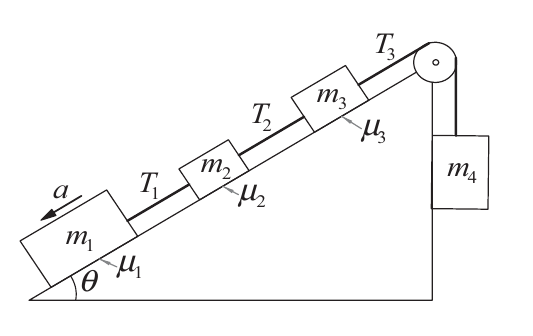

</center>

Cuatro bloques de masas diferentes $m_i$ están conectados mediante cuerdas de masa despreciable. Tres de los bloques se encuentran sobre un plano inclinado con un ángulo $\theta$, donde los coeficientes de fricción entre los bloques y el plano son $\mu_i$. Las ecuaciones de movimiento del sistema son:

$$
T_1 + m_1a = m_1g(\sin \theta - \mu_1 \cos \theta) 
$$
$$
-T_1 + T_2 + m_2a = m_2g(\sin \theta - \mu_2 \cos \theta) 
$$
$$
-T_2 + T_3 + m_3a = m_3g(\sin \theta - \mu_3 \cos \theta) 
$$
$$
-T_3 + m_4a = -m_4g
$$

donde:
- $T_i$ representa las tensiones en las cuerdas.
- $a$ es la aceleración del sistema.
- $\theta = 45^\circ$ es el ángulo de inclinación.
- $g = 9.81\ m/s^2$ es la aceleración gravitacional.

Determina $a$ y $T_i$.

**Datos:**

Masas de los bloques:
$$
\mathbf{m} = \begin{bmatrix}
10 & 4 & 5 & 6 \\
\end{bmatrix}^T kg
$$

Coeficientes de fricción:
$$
\mu = \begin{bmatrix}
0.25 & 0.3 & 0.2 \\
\end{bmatrix}^T
$$


In [3]:
# Datos del problema
masas = np.array([10, 4, 5, 6])  # masas en kg
mu = np.array([0.25, 0.3, 0.2])  # coeficientes de fricción
theta = np.radians(45)  # ángulo en radianes
g = 9.81  # aceleración gravitacional

# Matriz de coeficientes A
A = np.array([
    [1, 0, 0, masas[0]],
    [-1, 1, 0, masas[1]],
    [0, -1, 1, masas[2]],
    [0, 0, -1, masas[3]]
])

# Vector de términos independientes b
sin_theta = np.sin(theta)
cos_theta = np.cos(theta)

b = np.array([
    masas[0] * g * (sin_theta - mu[0] * cos_theta),
    masas[1] * g * (sin_theta - mu[1] * cos_theta),
    masas[2] * g * (sin_theta - mu[2] * cos_theta),
    -masas[3] * g
])

# Resolver el sistema
x = np.linalg.solve(A, b)

# Extraer tensiones y aceleración
T1, T2, T3, a = x

# Mostrar resultados
print("Solución:")
print(f"Tensión T1: {T1:.2f} N")
print(f"Tensión T2: {T2:.2f} N")
print(f"Tensión T3: {T3:.2f} N")
print(f"Aceleración a: {a:.2f} m/s²")


Solución:
Tensión T1: 35.89 N
Tensión T2: 48.86 N
Tensión T3: 68.54 N
Aceleración a: 1.61 m/s²


# 3.
Considera el circuito de la figura. Usando las leyes de Kirchhoff, escribe las ecuaciones de corriente y voltaje. Luego, determina la forma matricial y encuentra los valores de la corriente que fluye por cada rama, es decir, $i_{12}$, $i_{23}$ y así sucesivamente.

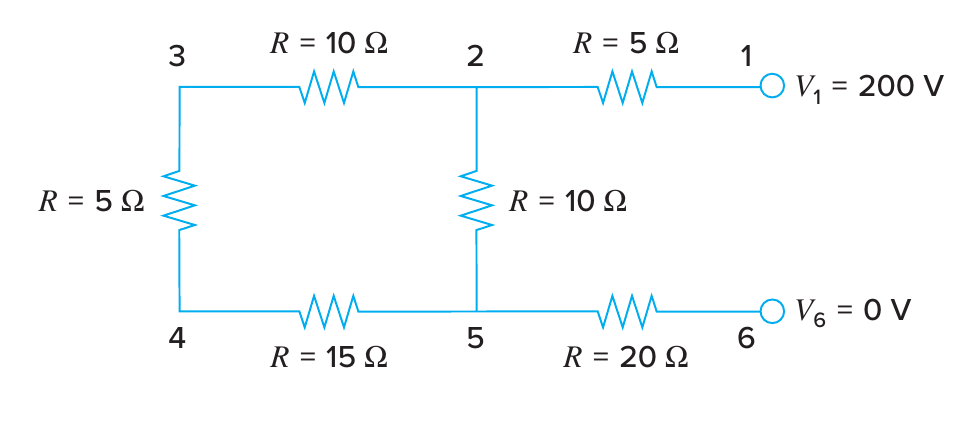


$$i_{12}-i_{23}-i_{25}=0$$
$$i_{23}-i_{34}=0$$
$$i_{34}-i_{45}=0$$
$$i_{45}-i_{25}-i_{56}=0$$
$$R_1 i_{12}+R_5 i_{25}+R_6 i_{56}=200$$
$$R_5 i_{25}-R_2 i_{23}-R_3 i_{34}-R_4 i_{45}=0$$

In [4]:
# Definir los valores de las resistencias y las fuentes de voltaje
R1 = 5  # Ohm
R2 = 10  # Ohm
R3 = 5  # Ohm
R4 = 15  # Ohm
R5 = 10  # Ohm
R6 = 20  # Ohm
V1 = 200  # En voltios

# Definir la matriz de coeficientes (A) y el vector de términos independientes (B)
A = np.array([
    [1, -1, 0, 0, 0, -1],   # Nodo 1
    [0, 1, -1, 0, 0, 0],    # Nodo 2
    [0, 0, 1, -1, 0, 0],    # Nodo 3
    [0, 0, 0, 1, -1, 1],    # Nodo 4    
    [R1, 0, 0, 0, R6, R5],  # Malla 1 
    [0, -R2, -R3, -R4, 0, R5] # Malla 2   
])

B = np.array([0, 0, 0, 0, V1, 0])

# Resolver el sistema de ecuaciones lineales
corrientes = np.linalg.solve(A, B)

# Mostrar los resultados
i12, i23, i34, i45, i56, i25 = corrientes
print(f"Corriente i12: {i12:.3f} A")
print(f"Corriente i23: {i23:.3f} A")
print(f"Corriente i34: {i34:.3f} A")
print(f"Corriente i45: {i45:.3f} A")
print(f"Corriente i56: {i56:.3f} A")
print(f"Corriente i25: {i25:.3f} A")


Corriente i12: 6.154 A
Corriente i23: 1.538 A
Corriente i34: 1.538 A
Corriente i45: 1.538 A
Corriente i56: 6.154 A
Corriente i25: 4.615 A


# 4. 
Considere la siguiente matriz $\mathbf{A}$:

$$\mathbf{A} = \begin{pmatrix} 2 & 3 & 1 \\ 4 & 7 & 3 \\ 6 & 18 & 5 \end{pmatrix}$$

- Calcule la factorización $\mathbf{LU}$ de la matriz $\mathbf{A}$, donde $\mathbf{L}$ es una matriz triangular inferior con unos en la diagonal y $\mathbf{U}$ es una matriz triangular superior.
- Use la factorización $\mathbf{LU}$ obtenida en el paso anterior para encontrar la matriz inversa $\mathbf{A}^{-1}$. Para esto, resuelve los siguientes dos sistemas matriciales, basados en la ecuación $\mathbf{L}\mathbf{U}\mathbf{A}^{-1} = \mathbf{I}$, donde $\mathbf{I}$ es la matriz identidad de $3 \times 3$:
    - Resuelva $\mathbf{L}\mathbf{Z} = \mathbf{I}$ para la matriz intermedia $\mathbf{Z}$.
    - Resuelva $\mathbf{U}\mathbf{A}^{-1} = \mathbf{Z}$ para la matriz inversa $\mathbf{A}^{-1}$.


In [5]:
def descomposicion_lu(A):
    """
    Calcula la factorización LU de la matriz A, donde L es una matriz triangular
    inferior con unos en la diagonal y U es una matriz triangular superior.
    
    Esta función implementa el algoritmo de Doolittle (L tiene unos en la diagonal).
    No se usa pivoteo, por lo que la función puede fallar si se encuentra un pivote cero.
    
    Parámetros:
    A (numpy.ndarray): matriz cuadrada de coeficientes (n x n).

    Retorna:
    L (numpy.ndarray): matriz triangular inferior con unos en la diagonal.
    U (numpy.ndarray): matriz triangular superior.
    """
    n = A.shape[0]
    # Inicializar L como la identidad y U como una copia de A.
    U = A.astype(float).copy() 
    L = np.eye(n, dtype=float)
    
    for k in range(n-1):
        # Verificar si hay pivote cero (requerido para LU sin pivoteo)
        if abs(U[k, k]) < 1e-15:
            # Para una implementación completa, se requeriría pivoteo parcial.
            raise ValueError("La descomposición LU falló: se encontró un pivote cero.")

        for i in range(k + 1, n):
            # Calcular el multiplicador (L[i, k])
            factor = U[i, k] / U[k, k]
            L[i, k] = factor # Guardar el factor en L
            
            # Realizar la operación de fila en U (eliminando U[i, k] hasta cero)
            U[i, k:] = U[i, k:] - factor * U[k, k:]
            
    # U es la parte triangular superior de la A modificada.
    # L se construye a partir de los factores.
    return L, U


In [6]:
def resolver_triangular_inferior(L, b):
    """
    Resuelve el sistema Lx = b para x usando sustitución hacia adelante.
    
    Parámetros:
    L (numpy.ndarray): matriz triangular inferior (n x n).
    b (numpy.ndarray): vector o matriz del lado derecho (n, m o n,).
    
    Retorna:
    x (numpy.ndarray): vector solución.
    """
    n = L.shape[0]

    x = np.zeros_like(b, dtype=float)
    for i in range(n):
        # L[i, i] es 1
        # x[i] = (b[i] - sum(L[i, j] * x[j] para j desde 0 hasta i-1)) / L[i, i]
        x[i] = b[i] - np.dot(L[i, :i], x[:i])
    return x



In [7]:
def resolver_triangular_superior(U, b):
    """
    Resuelve el sistema Ux = b para x usando sustitución hacia atrás.
    
    Parámetros:
    U (numpy.ndarray): matriz triangular superior (n x n).
    b (numpy.ndarray): vector o matriz del lado derecho (n, m o n,).
        
    Retorna:
    x (numpy.ndarray): vector solución.
    """
    n = U.shape[0]
    x = np.zeros_like(b, dtype=float)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
    return x


In [8]:
def inversa_por_lu(A):
    """
    Calcula la inversa de la matriz A usando factorización LU.
    
    Parámetros:
    A (numpy.ndarray): matriz cuadrada (n x n).
    
    Retorna:
    A_inv (numpy.ndarray): matriz inversa A^{-1}.
    L (numpy.ndarray): matriz triangular inferior.
    U (numpy.ndarray): matriz triangular superior.
    Z (numpy.ndarray): matriz intermedia Z.
    """
    n = A.shape[0]
    I = np.eye(n, dtype=float)
    
    # 1. Descomposición LU
    L, U = descomposicion_lu(A)
    
    # 2. Resolver L*Z = I para Z (sustitución hacia adelante)
    Z = resolver_triangular_inferior(L, I)
    
    # 3. Resolver U*A_inv = Z para A_inv (sustitución hacia atrás)
    A_inv = resolver_triangular_superior(U, Z)
    
    return A_inv, L, U, Z


In [9]:
A = np.array([
    [2, 3, 1], 
    [4, 7, 3], 
    [6, 18, 5]
])

In [10]:
A_inv, L, U, Z = inversa_por_lu(A)

print("Factorización LU de A")
print("Matriz triangular inferior L:")
print(L)
print("Matriz triangular superior U:")
print(U)
print(f"Matriz intermedia Z: ")
print(Z)

print("Matriz inversa A⁻¹")
print(A_inv)

# Para comparar, calcular la inversa usando la función estándar de NumPy
A_inv_np = np.linalg.inv(A)
print("Inversa calculada por numpy.linalg.inv para comparar:")
print(A_inv_np)


Factorización LU de A
Matriz triangular inferior L:
[[1. 0. 0.]
 [2. 1. 0.]
 [3. 9. 1.]]
Matriz triangular superior U:
[[ 2.  3.  1.]
 [ 0.  1.  1.]
 [ 0.  0. -7.]]
Matriz intermedia Z: 
[[ 1.  0.  0.]
 [-2.  1.  0.]
 [15. -9.  1.]]
Matriz inversa A⁻¹
[[ 1.35714286 -0.21428571 -0.14285714]
 [ 0.14285714 -0.28571429  0.14285714]
 [-2.14285714  1.28571429 -0.14285714]]
Inversa calculada por numpy.linalg.inv para comparar:
[[ 1.35714286 -0.21428571 -0.14285714]
 [ 0.14285714 -0.28571429  0.14285714]
 [-2.14285714  1.28571429 -0.14285714]]


# 5.
El método de Jacobi reescribe el sistema $ Ax = b $ descomponiendo la matriz $ A $ como:

$$
A = D + L + U,
$$

donde:
- $ D $: matriz diagonal de $ A $.
- $ L $: matriz triangular inferior sin la diagonal.
- $ U $: matriz triangular superior sin la diagonal.

El sistema se reorganiza como:

$$
x = D^{-1}(b - (L + U)x).
$$

Esto se implementa iterativamente como:

$$
x_i^{(k+1)} = \frac{1}{a_{ii}} \left(b_i - \sum_{j \neq i} a_{ij} x_j^{(k)}\right),
$$

donde $ a_{ii} $ son los elementos diagonales de $ A $.

- Escriba una función explícita que realice iterativamente este método con una tolerancia de 1e-7 y un máximo de 100 iteraciones. Define una documentación clara que explique los métodos usados, las entradas y las salidas.

- Para una matriz aleatoria de $5 \times 5$, encuentre la solución usando tu función y determina el error con respecto a `np.linalg.solve` y al método de la matriz inversa.


In [11]:
def jacobi(A, b, tol=1e-7, max_iter=100):
    """
    Resuelve el sistema de ecuaciones lineales Ax = b usando el método de Jacobi.

    Parámetros:
    A (numpy.ndarray): matriz de coeficientes de tamaño n x n.
    b (numpy.ndarray): vector de términos independientes de tamaño n.
    tol (float): tolerancia de convergencia (por defecto 1e-7).
    max_iter (int): número máximo de iteraciones (por defecto 100).

    Retorna:
    x (numpy.ndarray): solución aproximada del sistema.
    iteraciones (int): número de iteraciones realizadas.
    """
    n = len(b)  # Tamaño del sistema
    x = np.random.rand(n)  # Inicialización del vector solución
    
    # Descomposición de A en D, L y U
    D = np.diag(np.diag(A))  # Matriz diagonal
    L_mas_U = A - D  # Matriz L + U
    
    # Iteraciones del método de Jacobi
    for iteracion in range(max_iter):
        x_nuevo = np.linalg.inv(D)@(b - L_mas_U@x)
        
        # Verificar convergencia
        if np.linalg.norm(x_nuevo - x) < tol:
            break
        
        x = x_nuevo
    
    return x_nuevo, iteracion + 1



In [12]:
def jacobi_por_componentes(A, b, tol=1e-7, max_iter=100):
    """
    Resuelve un sistema de ecuaciones lineales Ax = b usando el método iterativo
    de Jacobi, implementando explícitamente la fórmula componente a componente.

    La convergencia suele estar garantizada si la matriz A es estrictamente
    diagonalmente dominante.

    Argumentos:
        A (numpy.ndarray): matriz de coeficientes de tamaño n x n.
        b (numpy.ndarray): vector de términos independientes de tamaño n.
        tol (float): tolerancia de convergencia (por defecto 1e-7).
        max_iter (int): número máximo de iteraciones (por defecto 100).

    Retorna:
        Una tupla que contiene:
        - x: vector solución (arreglo de NumPy).
        - k: número de iteraciones realizadas.
        - error: norma L2 final del cambio en el vector solución.
    """
    n = A.shape[0]

    # --- Validación de entrada ---
    if A.shape != (n, n):
        raise ValueError("La matriz A debe ser cuadrada.")
    if b.shape != (n,):
        raise ValueError("El vector b debe tener la misma dimensión que A.")

    # Verificar si hay elementos diagonales iguales a cero
    if np.any(np.diag(A) == 0):
        raise ValueError("La matriz A tiene cero(s) en la diagonal. No se puede realizar la iteración de Jacobi.")

    # --- Inicialización ---
    # Inicializar el vector solución x con ceros
    x = np.zeros_like(b, dtype=float)

    # --- Bucle de iteración ---
    for k in range(max_iter):
        x_nuevo = np.zeros_like(x)

        # Recorrer cada componente i para calcular x_i^(k+1)
        for i in range(n):
            # Calcular el término de sumatoria: SUMA_{j != i} (a_ij * x_j^(k))
            suma = 0.0
            for j in range(n):
                if i != j:
                    suma += A[i, j] * x[j]

            # Aplicar la fórmula de Jacobi para la i-ésima componente
            # x_i^(k+1) = (1 / a_ii) * (b_i - suma)
            x_nuevo[i] = (b[i] - suma) / A[i, i]

        # Verificar la convergencia: norma L2 de la diferencia entre x^(k+1) y x^(k)
        error = np.linalg.norm(x_nuevo - x)

        if error < tol:
            return x_nuevo, k + 1, error

        # Actualizar x para la siguiente iteración
        x = x_nuevo

    # --- No convergencia ---
    raise RuntimeError(f"El método de Jacobi no convergió después de {max_iter} iteraciones. Error final: {error:.2e}")


In [13]:
# Ejemplo de uso
np.random.seed(30)
n = 5  # Para reproducibilidad
A = np.random.rand(n, n)  # Matriz aleatoria de 5x5
A = A + n/3 * np.eye(n)  # Asegurar que A sea diagonalmente dominante
b = np.random.rand(n)  # Vector aleatorio de términos independientes

# Resolver usando el método de Jacobi
x_jacobi, iteraciones = jacobi(A, b)
print("Solución usando Jacobi:")
print(x_jacobi)
print(f"Iteraciones realizadas: {iteraciones}")

# Resolver usando np.linalg.solve (solución exacta)
x_exacta = np.linalg.solve(A, b)
print("\nSolución exacta (np.linalg.solve):")
print(x_exacta)

# Resolver usando el método de la inversa
x_inversa = np.linalg.inv(A)@b
print("\nSolución usando la matriz inversa:")
print(x_inversa)

# Calcular errores
error_jacobi = np.linalg.norm(x_jacobi - x_exacta)
error_inversa = np.linalg.norm(x_jacobi - x_inversa)

print("\nError con respecto a np.linalg.solve:")
print(f"Error relativo a solve: {error_jacobi}")
print(f"Error relativo a la inversa: {error_inversa}")


Solución usando Jacobi:
[ 0.02399689  0.19737068  0.10376859 -0.07465053  0.10310298]
Iteraciones realizadas: 100

Solución exacta (np.linalg.solve):
[ 0.02399684  0.19737065  0.10376855 -0.07465057  0.10310294]

Solución usando la matriz inversa:
[ 0.02399684  0.19737065  0.10376855 -0.07465057  0.10310294]

Error con respecto a np.linalg.solve:
Error relativo a solve: 8.424862135592863e-08
Error relativo a la inversa: 8.424862135602325e-08


# 6.
Considere la siguiente matriz $2 \times 2$ $\mathbf{A}$:

$$\mathbf{A} = \begin{pmatrix} 4 & 1 \\ 2 & 3 \end{pmatrix}$$

- Hallar los valores propios ($\lambda$):
    - Escriba la ecuación característica para $\mathbf{A}$, que es $\det(\mathbf{A} - \lambda \mathbf{I}) = 0$.
    - Resuelva la ecuación cuadrática resultante para encontrar los dos valores propios, $\lambda_1$ y $\lambda_2$.
    
- Verificación usando la traza y el determinante:
    
    Para una matriz $2 \times 2$ $\mathbf{A}$, la ecuación característica también se puede escribir usando la traza ($\text{Tr}(\mathbf{A})$) y el determinante ($\det(\mathbf{A})$) como:
    
    $$\lambda^2 - \text{Tr}(\mathbf{A})\lambda + \det(\mathbf{A}) = 0$$

    $$\lambda_{\pm}=\frac{\text{Tr}(\mathbf{A}) \pm \sqrt{\text{Tr}^2(\mathbf{A})- 4\det(\mathbf{A})}}{2} $$


In [14]:
A = np.array([[4, 1],
              [2, 3]])

# Valores propios usando NumPy
valores_propios = np.linalg.eigvals(A)
print("Valores propios con NumPy:", valores_propios)

# Manualmente:
traza = np.trace(A)
det = np.linalg.det(A)

# Ecuación característica: λ^2 - traza * λ + det = 0
D = traza**2 - 4*det
lambda1 = (traza + np.sqrt(D)) / 2
lambda2 = (traza - np.sqrt(D)) / 2
print("Valores propios con traza y determinante:", lambda1, lambda2)


Valores propios con NumPy: [5. 2.]
Valores propios con traza y determinante: 4.999999999999999 2.000000000000001


# 7.
Considere una partícula cuyo hamiltoniano es $ H = \begin{pmatrix} 2 & i & 0 \\ -i & 1 & 1 \\ 0 & 1 & 0 \end{pmatrix} $.

- ¿Es $H$ hermítica?
- Encuentre los valores propios (energías) y los vectores propios normalizados de $H$.


In [15]:
# Definir la matriz H
H = np.array([[2, 1j, 0],
              [-1j, 1, 1],
              [0, 1, 0]], dtype=complex)

# Verificar si H es hermítica
H_daga = np.conj(H).T
es_hermitiana = np.allclose(H, H_daga)

print("¿H es hermítica?", "Sí" if es_hermitiana else "No")


¿H es hermítica? Sí


In [16]:
# Calcular valores propios y vectores propios
valores_propios, vectores_propios = np.linalg.eigh(H)  # eigh es para matrices hermíticas

print("Valores propios (energías):")
print(valores_propios)

print("Vectores propios normalizados (columnas):")
print(vectores_propios)

# Verificar la normalización
print("Verificación de normalización:")
for i in range(3):
    norma = np.linalg.norm(vectores_propios[:, i])
    print(f"Vector {i+1}: norma = {norma:.6f}")


Valores propios (energías):
[-0.73205081  1.          2.73205081]
Vectores propios normalizados (columnas):
[[-0.21132487+0.j          0.57735027-0.j         -0.78867513+0.j        ]
 [ 0.        -0.57735027j  0.        +0.57735027j  0.        +0.57735027j]
 [ 0.        +0.78867513j  0.        +0.57735027j  0.        +0.21132487j]]
Verificación de normalización:
Vector 1: norma = 1.000000
Vector 2: norma = 1.000000
Vector 3: norma = 1.000000
